# Solar Filament Segmentation Challenge 2026
## U-Net + ConvNeXt training, evaluation, and inference

This notebook is the pipeline driver: it installs the extra deep-learning
dependencies, points the shared config at Kaggle's `/kaggle/input` mounts,
then calls the same `scripts/train.py` / `scripts/evaluate.py` / `scripts/infer.py`
used locally -- so the logic lives in one place (the code dataset attached to
this kernel), not duplicated into notebook cells.

**Task**: binary, category-agnostic filament segmentation (the competition's
Overview page states class labels are out of scope for scoring). A U-Net with a
ConvNeXt-Tiny encoder predicts a foreground probability map; watershed
post-processing splits it into individual filament instances for the
Panoptic-Quality-scored submission format.

### 0. Confirm the mounted data layout
Adjust `configs/config_kaggle.yaml`'s `data:` paths if this doesn't match.

In [1]:
!git clone https://github.com/jprakash-1/Solar-Filament-Segmentation.git

fatal: destination path 'Solar-Filament-Segmentation' already exists and is not an empty directory.


In [2]:
%cd /kaggle/working/Solar-Filament-Segmentation
!ls

/kaggle/working/Solar-Filament-Segmentation
configs		 outputs	   solar-filament-segmentation-analysis.ipynb
data		 README.md	   src
kaggle_notebook  requirements.txt  state.db
kaggle_package	 scripts


In [3]:
!find /kaggle/input -maxdepth 3

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/filament-segmentation-2026
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026


### 1. Bring in the code dataset and install missing dependencies

In [4]:
!git pull origin master 

From https://github.com/jprakash-1/Solar-Filament-Segmentation
 * branch            master     -> FETCH_HEAD
Already up to date.


In [5]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00


In [6]:
import torch
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))

torch 2.10.0+cu128
cuda available: True
device: Tesla T4


### 2. Train
`configs/config_kaggle.yaml` sets `image_size: 2048` (native resolution) and a GPU-sized
`batch_size` (default 4 -- raise/lower depending on VRAM). Override any config value
from the CLI, e.g. `--epochs` / `--batch-size`, without editing the file.

In [7]:
!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") \
    scripts/train.py --config configs/config_kaggle.yaml --resume

W0822 06:59:08.295000 126 torch/distributed/run.py:852] 
W0822 06:59:08.295000 126 torch/distributed/run.py:852] *****************************************
W0822 06:59:08.295000 126 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0822 06:59:08.295000 126 torch/distributed/run.py:852] *****************************************
Using device: cuda:0 (DDP, world_size=2)
train images: 1039  val images: 115
Train augmentations: RandomResizedCrop -> HorizontalFlip -> VerticalFlip -> RandomRotate90 -> Affine -> RandomBrightnessContrast -> Normalize -> ToTensorV2
Val transforms:      Resize -> Normalize -> ToTensorV2
Batches per epoch: 86 train, 10 val (batch_size=6/rank, global=12, num_workers=4)
model.safetensors: 100%|█████████████████████| 114M/114M [00:01<00:00, 62.2MB/s]
Model: tu-convnext_tiny encode

### 3. Training curve

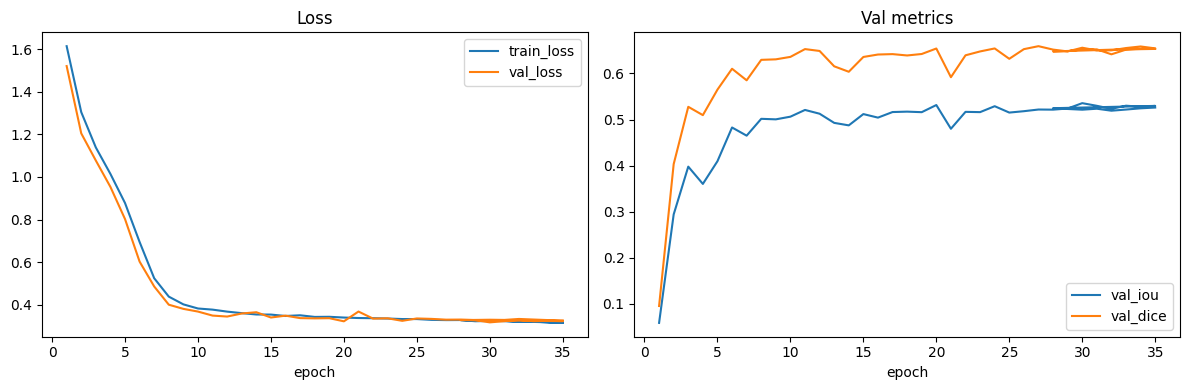

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv('outputs/logs/train_log.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log['epoch'], log['train_loss'], label='train_loss')
axes[0].plot(log['epoch'], log['val_loss'], label='val_loss')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('Loss')
axes[1].plot(log['epoch'], log['val_iou'], label='val_iou')
axes[1].plot(log['epoch'], log['val_dice_torchmetrics'], label='val_dice')
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].set_title('Val metrics')
fig.tight_layout()
plt.show()

### 4. Evaluate (instance-level Panoptic Quality + Dice)
Runs the full inference + post-processing pipeline against the held-out val split's
ground truth -- the same instance-splitting logic used for the actual submission --
as a local sanity check against the competition's real leaderboard metric.

In [9]:
!python scripts/evaluate.py --checkpoint outputs/checkpoints/best.pt --watershed-min-distance 140 --min-instance-area 40

Using device: cuda  (Tesla T4)
Evaluating on 115 val images (checkpoint epoch 27)
postprocess overrides: {'prob_threshold': 0.5, 'min_instance_area': 40, 'use_watershed': True, 'watershed_min_distance': 140}
evaluate: 100%|███████████████████████████████| 115/115 [02:09<00:00,  1.13s/it]
Computing mAP@[.5:.95]: 785 predicted instances vs 898 ground-truth instances across 115 images, over 10 IoU thresholds -- this is the slow part (full-resolution mask matching), progress bar below.
mAP thresholds: 100%|███████████████████████████| 10/10 [00:59<00:00,  5.92s/it]
mAP computation took 59.2s

mean Dice (semantic):  0.6717
mean IoU  (semantic):  0.5209
mean Panoptic Quality: 0.3392  (IoU thresh=0.5)
mAP@[.5:.95]:          0.1121
  AP@0.50:             0.3405
  AP@0.75:             0.0351


### 5. Inference -> submission CSV
Predicts on the test set, splits into filament instances, RLE-encodes each one, and
writes `outputs/submissions/submission_<timestamp>.csv` in the exact
`filament_id,segmentation_rle` format the competition expects.

In [9]:
!python scripts/infer.py --checkpoint outputs/checkpoints/best.pt --visualize 10

Using device: cuda
Running inference on 180 test images
infer: 100%|██████████████████████████████████| 180/180 [04:31<00:00,  1.51s/it]
Wrote 6246 filament rows for 180 images to outputs/submissions/submission_20260822_080037.csv
Saved visualizations to outputs/eda/predictions


In [10]:
import glob
import pandas as pd

submissions = sorted(glob.glob('outputs/submissions/*.csv'))
print('Latest submission:', submissions[-1] if submissions else 'none found')
pd.read_csv(submissions[-1]).head()

Latest submission: outputs/submissions/submission_20260822_080037.csv


,filament_id,segmentation_rle
0,20110120105534Ch_1,^`fi28go12K5N10101N010O100O1000O001G9Nb_YU1
1,20110120105534Ch_2,h`bj28go12H8O10O1O10O1OH9N]_iT1
2,20110120105534Ch_3,m`Rk28go12H8O100O10000O1O10000O100O001O01O10O1...
3,20110120105534Ch_4,ca`m25jo12J600O01000O1O001O10O001O001O0001O000...
4,20110120105534Ch_5,fh`R21no11N2M3N2M3N2O2J5O1M3_Oa0O1O1O1O01O001O...


### 6. Spot-check a few predictions

In [ ]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/eda/predictions/*.png'))[:3]:
    display(Image.open(path))

### Outputs
- `outputs/checkpoints/best.pt` / `last.pt` -- model weights
- `outputs/logs/train_log.csv` -- per-epoch metrics
- `outputs/submissions/submission_*.csv` -- ready to submit to the competition
- `outputs/eda/predictions/*.png` -- qualitative overlays

All of the above persist as this notebook's **Output** after a committed run,
downloadable via `kaggle kernels output <username>/filament-unet-convnext-training -p <local-dir>`.

In [ ]:
!ls

In [ ]:
%cd ..

In [ ]:
!zip -r  checkpoints.zip checkpoints

In [ ]:
!zip -r outputs.zip outputs/